Task 1: Exploratory Data Analysis (EDA)

1.	Load the dataset and perform fundamental data exploration.
2.	Utilize histograms, box plots, or density plots to understand feature distributions.
3.	Investigate feature correlations to discern relationships within the data.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [4]:
## 1.	Load the dataset and perform fundamental data exploration.

In [5]:
df = pd.read_csv('Pharma_Industry.csv')

In [6]:
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [8]:
df.shape

(500, 6)

In [9]:
df.isnull().sum()

,0
Drug Dosage (mg),0
Systolic Blood Pressure (mmHg),0
Heart Rate (BPM),0
Liver Toxicity Index (U/L),0
Blood Glucose Level (mg/dL),0
Drug Response,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


In [12]:
target = df['Drug Response']
features = df.drop(columns=['Drug Response'])

In [13]:
features.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL)
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355
4,0.377100,0.538410,-0.029263,1.896015,-0.960130


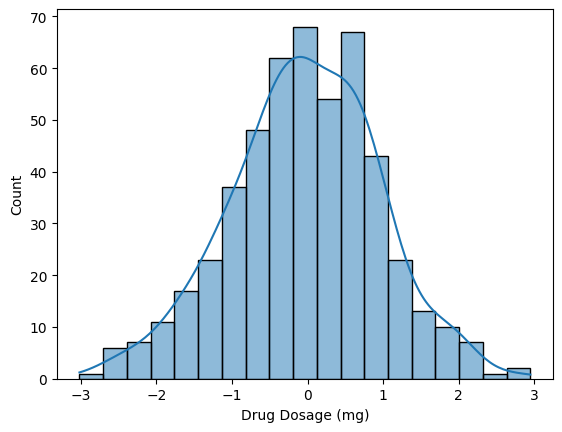

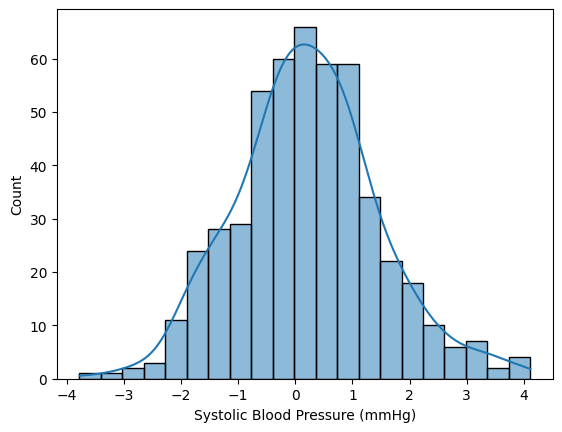

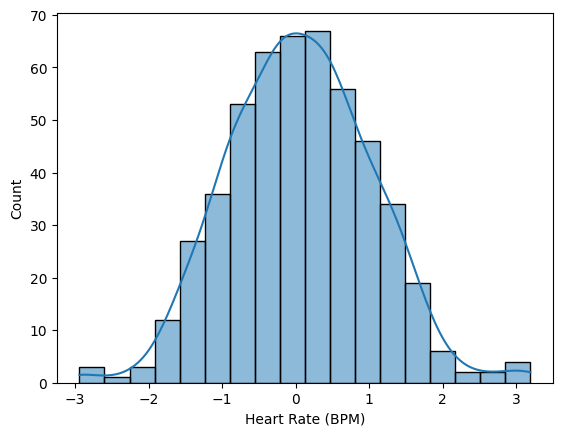

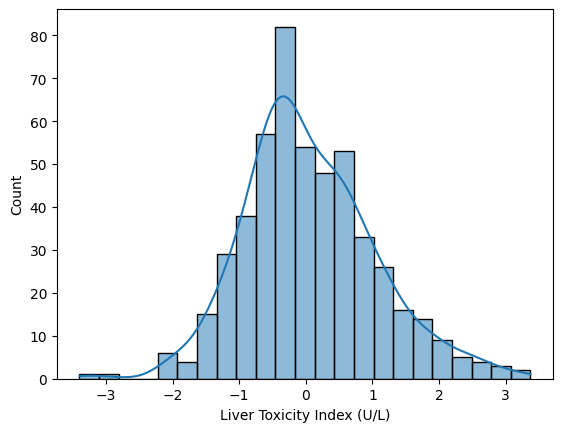

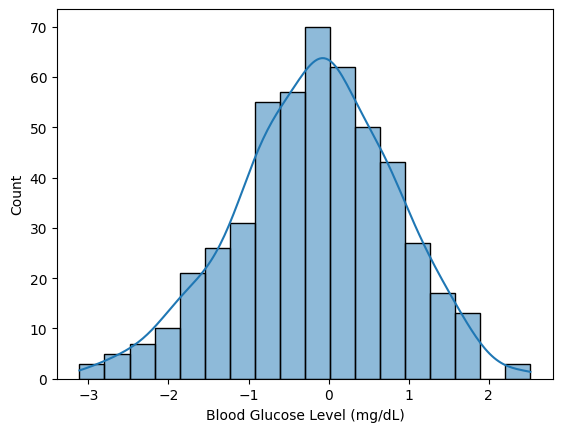

In [14]:
## Histogram
for col in features.columns:
    sns.histplot(features[col],kde=True)
    plt.show()

- From the histogram we can identify the distribution of data is normal or skewed.
- In the above histoplot columns Drug dosage, Heart Rate(BPM) and Liver toxicity Index have the perfect normal distribution. Because the plot of that columns are bell shaped.
- Other columns Blood Glucose Level,Systolic Blood Pressure have approximate normal distribution. The little skewness is equally shared

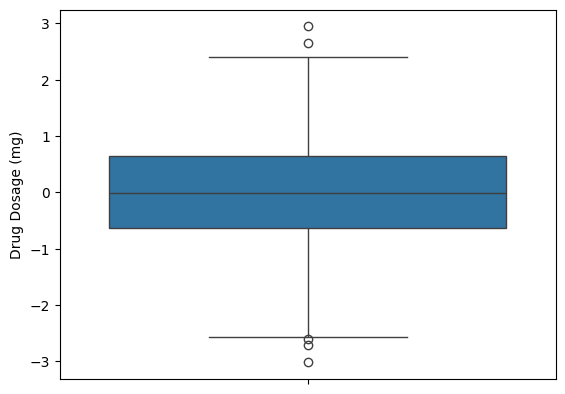

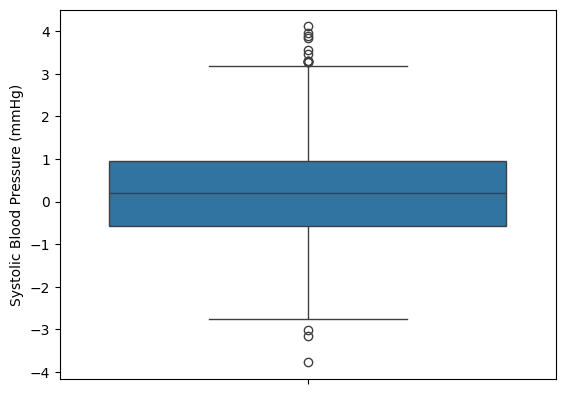

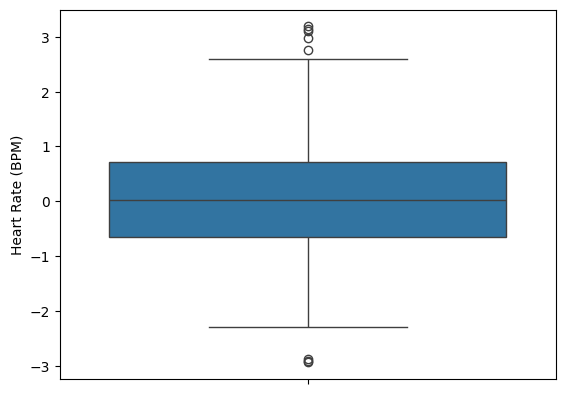

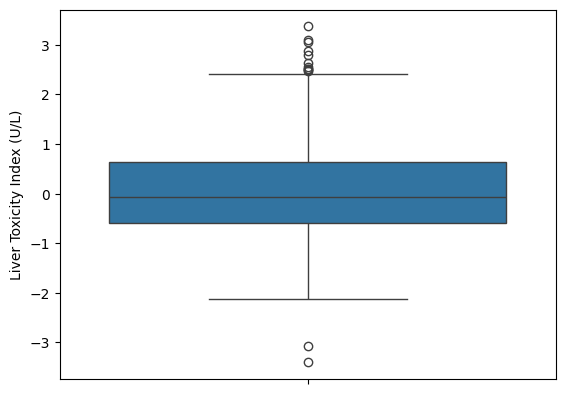

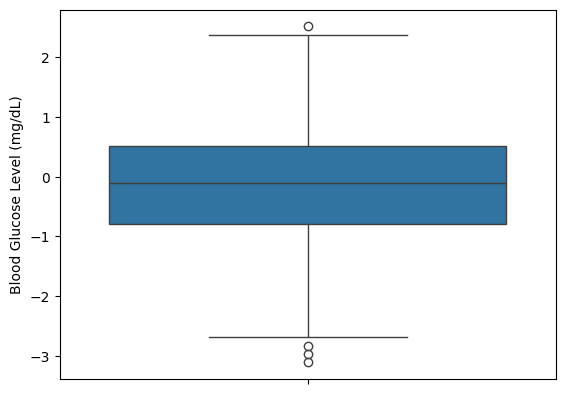

In [15]:
## Boxplot
for col in features.columns:
    sns.boxplot(features[col])
    plt.show()

- From Boxplot we can identify if any outliers in the data
- From the above graph we can see every feature having few outliers. And also the median of all features lies in the middle, that indicates the normal distribution. And the box size is medium sized it indicates the variability or IQR. Here the variability is normal

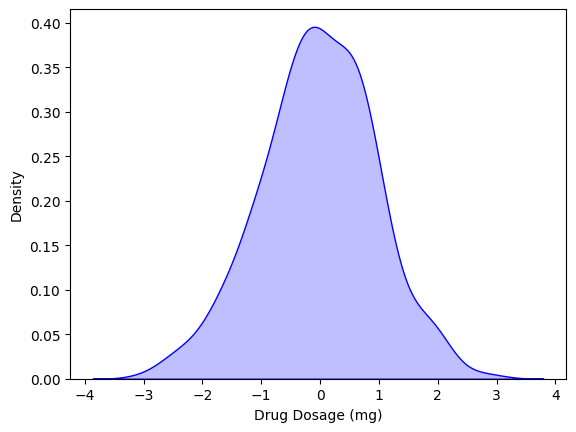

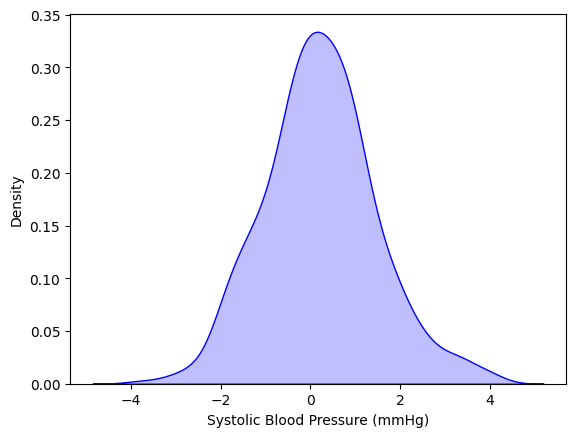

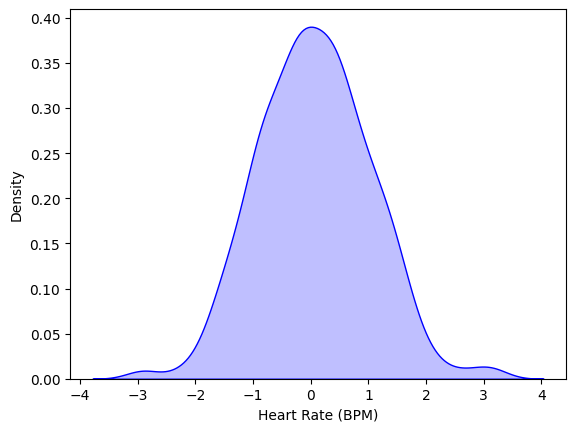

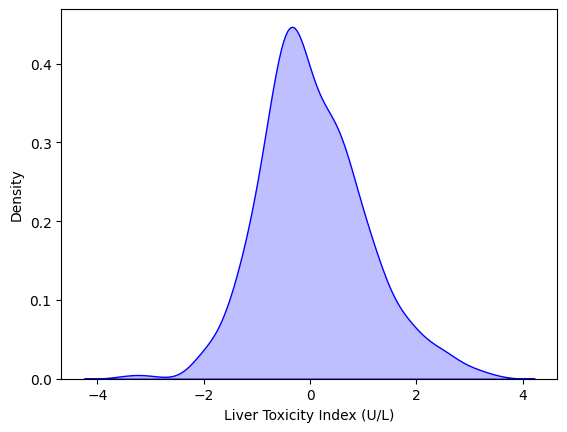

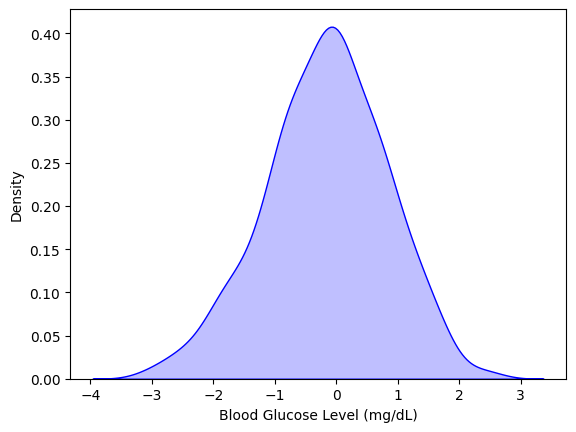

In [16]:
## Density Plot
for col in features.columns:
    sns.kdeplot(features[col],fill=True,color='blue')
    plt.show()

- From the density we can identify the distribution of the data. We can see Normal and skewed distribution from density plot.
- Above picture shows every feature have approximate normal distribution

In [17]:
## Investigate feature correlations to discern relationships within the data

In [18]:
df.corr()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
Drug Dosage (mg),1.000000,0.090618,0.040571,0.128127,0.012434,0.043457
Systolic Blood Pressure (mmHg),0.090618,1.000000,-0.039195,0.283672,0.037228,0.305226
Heart Rate (BPM),0.040571,-0.039195,1.000000,0.005818,0.049897,-0.009715
Liver Toxicity Index (U/L),0.128127,0.283672,0.005818,1.000000,0.229474,0.434722
Blood Glucose Level (mg/dL),0.012434,0.037228,0.049897,0.229474,1.000000,0.169342
Drug Response,0.043457,0.305226,-0.009715,0.434722,0.169342,1.000000


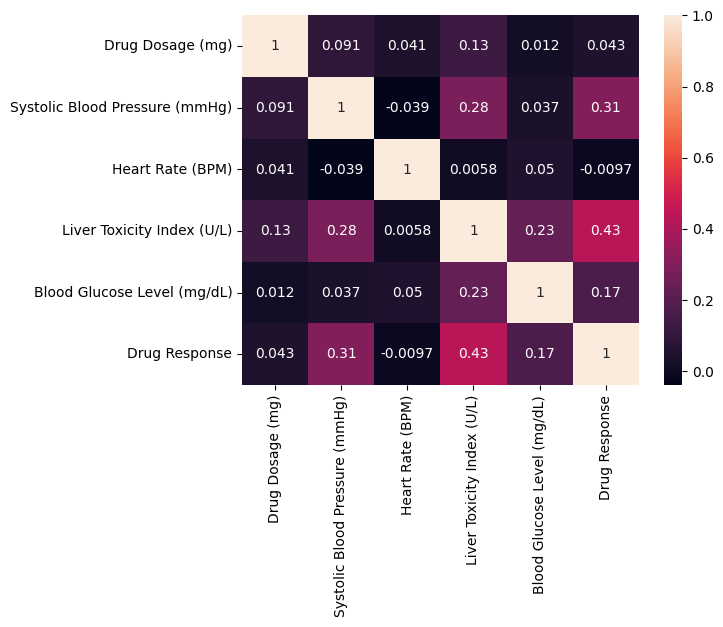

In [19]:
corr = df.corr()
sns.heatmap(corr,annot=True)
plt.show()

- From the above table and heatmap we can see that there is no correlation between columns.
- If the columns have correlation between them the value is > 0.5. But in here we can see that the values between each features is < 0.5.

Task 2: Data Preprocessing

1.	Encode categorical variables if necessary.
2.	Split the dataset into training and testing sets.

In [20]:
## 1. Encode categorical variables if necessary.

In [21]:
features.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL)
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355
4,0.377100,0.538410,-0.029263,1.896015,-0.960130


- There is no categorical variable in features

In [22]:
## 2. Split the dataset into training and testing sets

In [23]:
x_train,x_test,y_train,y_test = train_test_split(features,target,train_size=0.8,random_state=100,stratify=df['Drug Response'])
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(400, 5)
(100, 5)
(400,)
(100,)


Task 3: Data Visualization

1.	Employ scatter plots, pair plots, or relevant visualizations to comprehend feature distributions and relationships.
2.	Visualize class distributions to gauge dataset balance or imbalance.

In [24]:
## 1. Employ scatter plots, pair plots, or relevant visualizations to comprehend feature distributions and relationships.

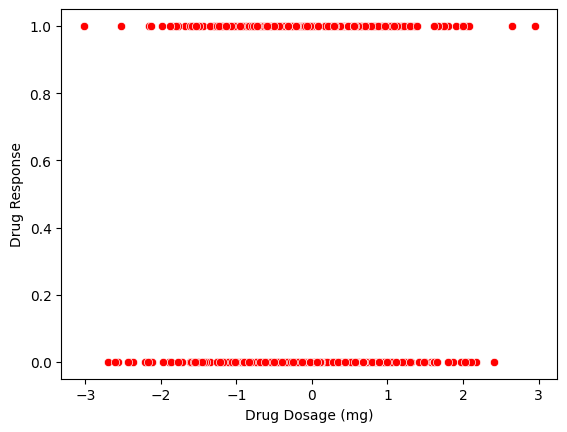

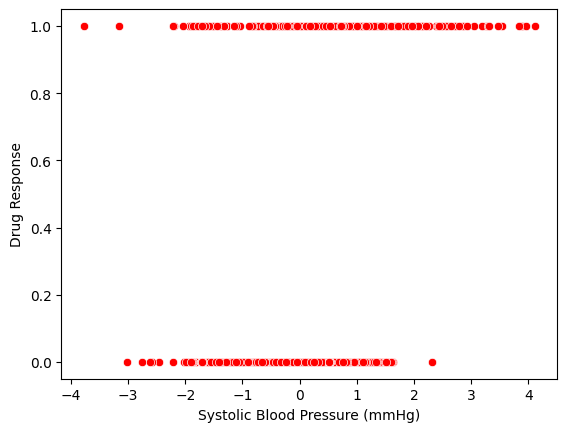

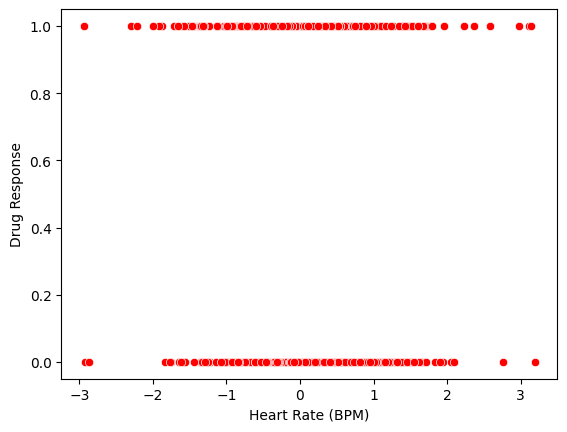

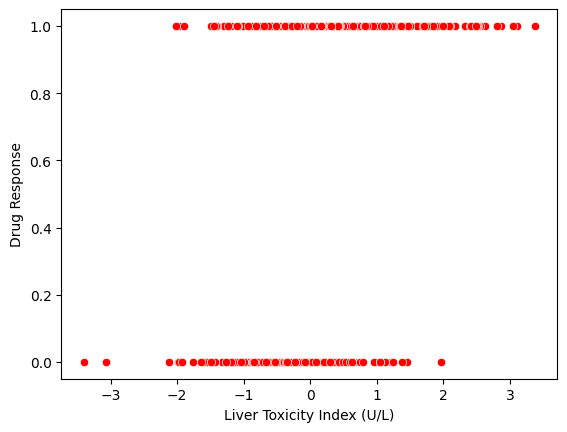

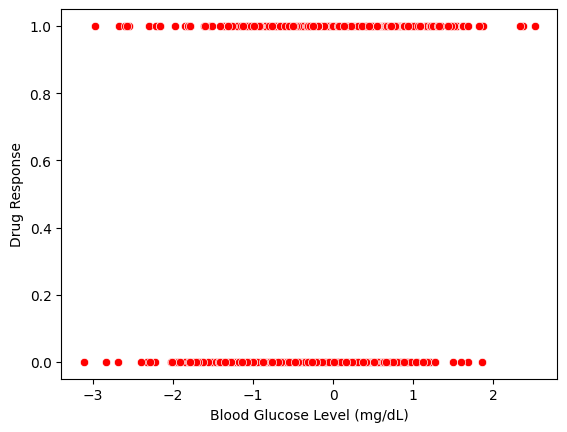

In [25]:
## Scatterplot
for col in df.columns:
  if col != 'Drug Response':
    sns.scatterplot(x=df[col],y=df['Drug Response'],color='red')
    plt.show()

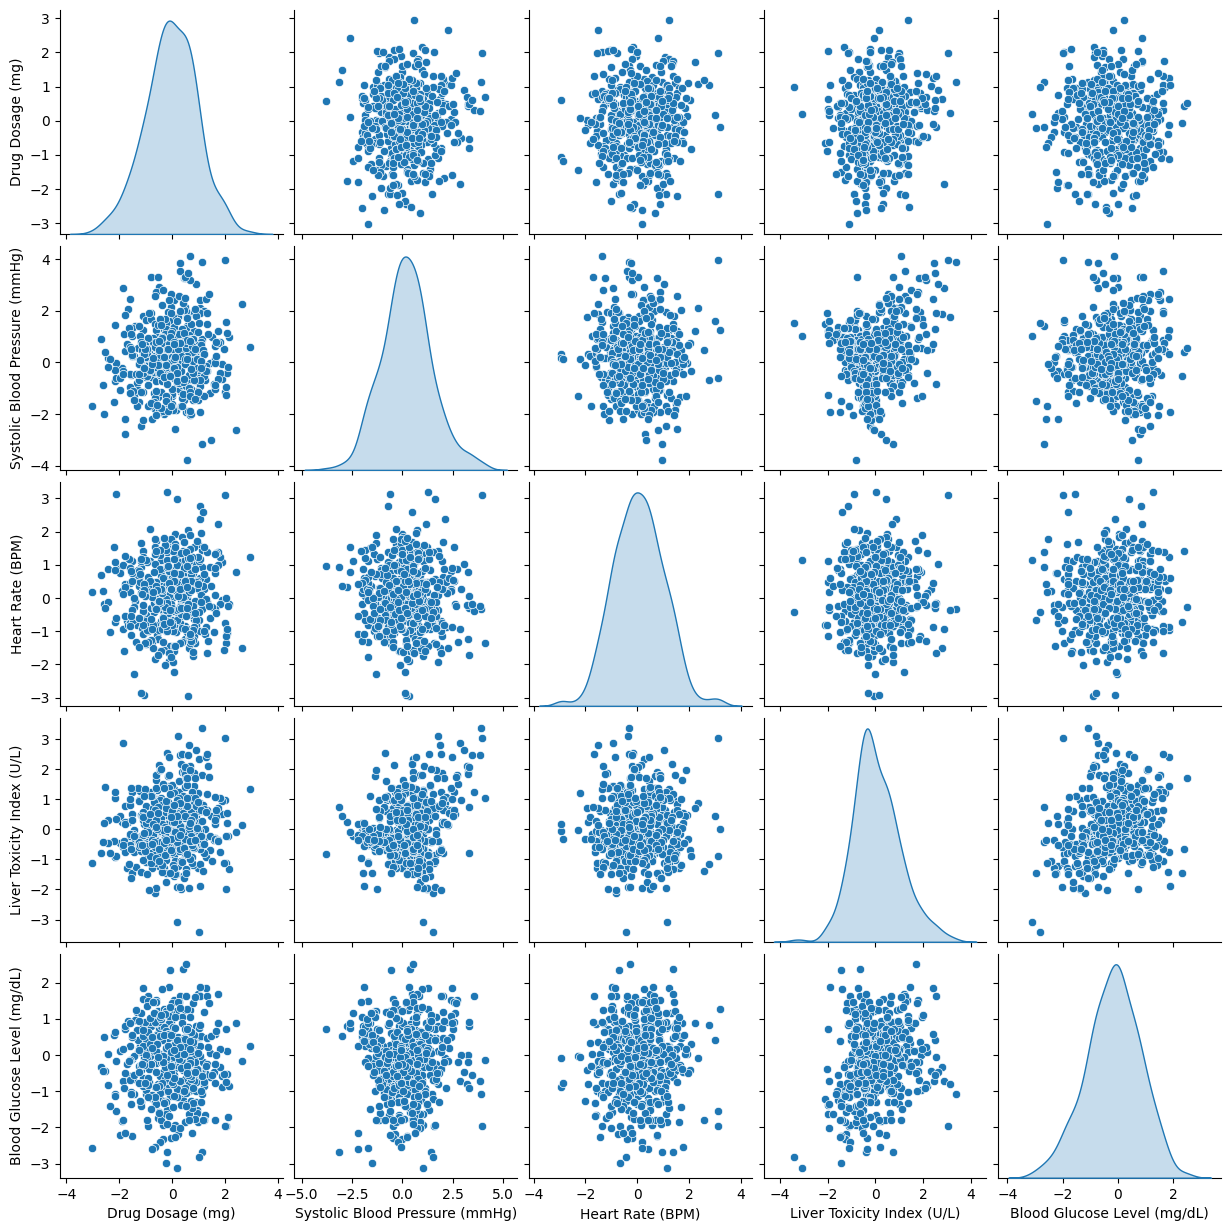

In [26]:
## Pairplot
sns.pairplot(features,diag_kind='kde')

The scatter plots show that the data points are distributed across two horizontal levels corresponding to the binary target variable (0 and 1). There is no clear separation or distinct pattern between the feature values and the target variable, indicating that individual features may not strongly influence the drug response when considered independently. The pair plot further confirms the absence of strong linear relationships between features and highlights the distribution of variables. This suggests that a combination of features may be required to effectively predict the target variable

In [27]:
## Visualize class distributions to gauge dataset balance or imbalance.

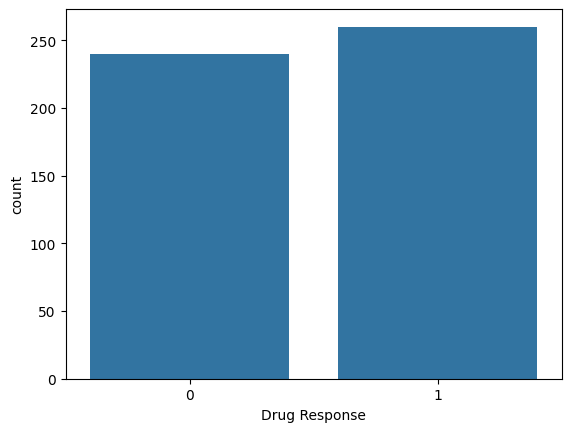

In [28]:
sns.countplot(x=df['Drug Response'],data = df)
plt.show()

In [29]:
df['Drug Response'].value_counts()

,count
Drug Response,
1,260
0,240


The class distribution plot indicates that one class has significantly more observations than the other, showing that the dataset is imbalanced. This may lead to biased model predictions

Task 4: SVM Implementation

1.	Implement a basic SVM classifier using Python libraries like scikit-learn.
2.	Train the SVM model on the training data.
3.	Evaluate model performance on the testing data using appropriate metrics (e.g., accuracy, precision, recall, F1-score).

In [30]:
## 1.Implement a basic SVM classifier using Python libraries like scikit-learn

In [31]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

In [32]:
x_train.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL)
59,0.331980,0.292810,0.190500,0.105008,0.010960
54,0.871297,0.154579,-1.345980,-0.292493,-0.780908
82,2.062525,-0.426294,-1.067533,0.548899,-0.539461
244,-1.776235,0.438991,0.408653,0.777159,0.724584
335,-0.369277,2.201547,0.143388,0.169955,0.405176


In [33]:
y_train.head()

,Drug Response
59,0
54,0
82,0
244,1
335,1


In [34]:
features.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL)
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355
4,0.377100,0.538410,-0.029263,1.896015,-0.960130


In [35]:
target.head()

,Drug Response
0,1
1,1
2,0
3,1
4,1


In [36]:
## 2. Train the SVM model on the training data.

In [37]:
## SVC training , kernel = Linear kernel
svc = SVC(C=1,kernel='linear')
svc.fit(x_train,y_train)

SVC(C=1, kernel='linear')

In [38]:
## 3. Evaluate model performance on the testing data using appropriate metrics (e.g., accuracy, precision, recall, F1-score).

In [39]:
y_pred = svc.predict(x_test)
accuracy_score(y_test,y_pred)

0.74

In [40]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.72      0.75      0.73        48
           1       0.76      0.73      0.75        52

    accuracy                           0.74       100
   macro avg       0.74      0.74      0.74       100
weighted avg       0.74      0.74      0.74       100



Task 5: Visualization of SVM Results

1.	Visualize classification results on the testing data.

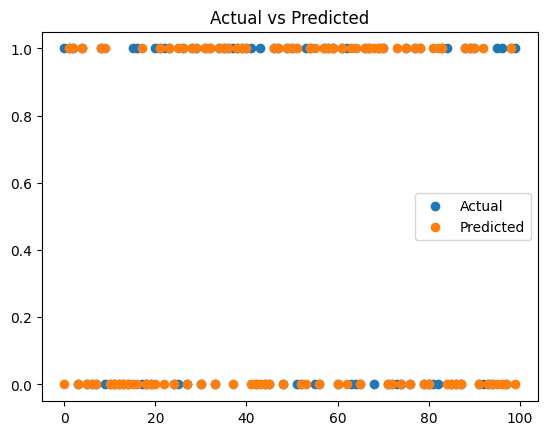

In [41]:
plt.scatter(range(len(y_test)), y_test, label='Actual')
plt.scatter(range(len(y_pred)), y_pred, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

In [42]:
from sklearn.metrics import confusion_matrix

In [43]:
conf_mat = confusion_matrix(y_test, y_pred)
print(conf_mat)

[[36 12]
 [14 38]]


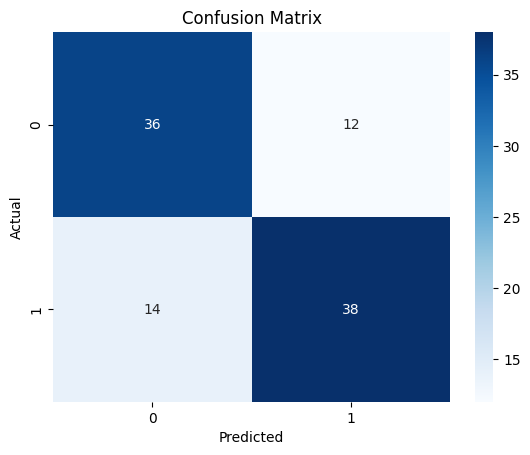

In [44]:
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

The confusion matrix shows that the model correctly predicted 36 negative cases and 38 positive cases. However, it misclassified 12 negative cases as positive (false positives) and 14 positive cases as negative (false negatives). The overall accuracy of the model is approximately 74%

Task 6: Parameter Tuning and Optimization

1.	Experiment with different SVM hyperparameters (e.g., kernel type, regularization parameter) to optimize performance.

In [62]:
## Kernel = Linear Kernel
C_values = [0.01, 0.1, 1, 10, 100]
for c in C_values:
    model = SVC(C=c, kernel='linear')
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    print('C =',c)
    print("Accuracy:", accuracy_score(y_test, y_pred))

C = 0.01
Accuracy: 0.73
C = 0.1
Accuracy: 0.73
C = 1
Accuracy: 0.74
C = 10
Accuracy: 0.74
C = 100
Accuracy: 0.74


The above result shows that the accyracy score is increase when the C value is increased.

In [57]:
## Kernel = Poly Kernel
C_values = [0.01, 0.1, 1, 10, 100]
for c in C_values:
    model = SVC(C=c, kernel='poly')
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    print('C =',c)
    print("Accuracy:", accuracy_score(y_test, y_pred))


C = 0.01
Accuracy: 0.62
C = 0.1
Accuracy: 0.7
C = 1
Accuracy: 0.77
C = 10
Accuracy: 0.75
C = 100
Accuracy: 0.74


The above result shows that the accuracy score is High when the value of C is 1, that is default. The accuracy score is minimum when the value of C is 0.01.

In [60]:
## Kernel = RBF
C_values = [0.01, 0.1, 1, 10, 100]
for c in C_values:
  svc2 = SVC(C=c, kernel='rbf')
  svc2.fit(x_train,y_train)
  y_pred2= svc2.predict(x_test)
  print('C = ',c)
  print('Accuracy =',accuracy_score(y_test,y_pred2))

C =  0.01
Accuracy = 0.52
C =  0.1
Accuracy = 0.78
C =  1
Accuracy = 0.79
C =  10
Accuracy = 0.79
C =  100
Accuracy = 0.75


The above result shows that the accuracy score is high when the value of C is 1 and 10. The accuracy is minimum when the value of C is 0.01.

In [61]:
## Kernel = Sigmoid Kernel
C_values = [0.01, 0.1, 1, 10, 100]
for c in C_values:
   svc3 = SVC(C=1,kernel='sigmoid',gamma=0.4,coef0=0.6)
   svc3.fit(x_train,y_train)
   y_pred3 = svc3.predict(x_test)
   print('C = ',c)
   print('Accuracy = ',accuracy_score(y_test,y_pred3))

C =  0.01
Accuracy =  0.5
C =  0.1
Accuracy =  0.5
C =  1
Accuracy =  0.5
C =  10
Accuracy =  0.5
C =  100
Accuracy =  0.5


The above result shows that the change in C values didn't affect the accuracy. In all case we got same accuracy score. Which means the model is not learn anything

Task 7: Comparison and Analysis

1.	Compare SVM performance with various kernels (e.g., linear, polynomial, radial basis function).
2.	Analyze SVM strengths and weaknesses for the dataset based on EDA and visualization results.
3.	Discuss practical implications of SVM in real-world classification tasks.

In [63]:
## 1. Compare SVM performance with various kernels (e.g., linear, polynomial, radial basis function)

Different SVM kernels and regularization parameter values were tested to optimize model performance. The linear kernel showed stable performance with accuracy around 74%, indicating the data is not strictly linearly separable. The polynomial kernel improved performance slightly, achieving 77% accuracy at C=1, but showed signs of overfitting at higher values of C. The RBF kernel performed the best, achieving the highest accuracy of 79% at C=1 and C=10, indicating that the dataset has non-linear patterns that are effectively captured by the RBF kernel. The sigmoid kernel performed poorly with accuracy around 50%, suggesting it is not suitable for this dataset. Therefore, the RBF kernel with C=1 or 10 is selected as the optimal model.

In [64]:
## 2. Analyze SVM strengths and weaknesses for the dataset based on EDA and visualization results.

Strength of SVM
- From EDA and scatter plots, the data does not appear to be linearly separable.
- The RBF kernel achieved the highest accuracy (79%), showing that SVM can handle complex, non-linear relationships effectively.
Weaknesses of SVM
- Performance varied significantly with different values of C
- SVM performance depends heavily on kernel selection. Because Sigmoid kernel performed poorly but RBF kernel achieved the highest accuracy.
- Scatter plots showed overlapping classes, indicating non-linear separability. Pair plots suggested complex relationships between features.

In [65]:
## Discuss practical implications of SVM in real-world classification tasks.

1. Medical Diagnosis
Used to identify disease Like above dataset we can take response and non response as target from patients.
2. Email spam detection and Sentimental analysis
SVM can handle high-dimensional data (text → many features)
3. Face recognition

SVM is a powerful and versatile classification algorithm used in many real-world applications such as healthcare, finance, and text classification. It performs well on complex and high-dimensional data but requires careful tuning and may lack interpretability in some applications.
